In [1]:
from google.colab import drive
import pandas as pd

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
netflix_dataset = pd.read_csv("/content/drive/MyDrive/Netflix/combined_data_1.txt.zip",header=None,names=['Cust_ID','Rating'],usecols=[0,1])

In [4]:
import os
os.listdir('/content/drive/MyDrive/Netflix')

['combined_data_1.txt.zip', 'movies (1) (1).csv']

In [5]:
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [7]:
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [ ]:
''' user     movie  rating
      user1    titanic     3
      user2                    4
      user3              5

User1 has not rated movie X
netflix answers How much will user1 probably lik this movie X?



In [ ]:
netflix_dataset

In [ ]:
''' 1:

      Movie 1

      user 1234    4
      user  456    5
      user 567     2

  2 :
    Movie 2
    user 456     3


  User   Movie   Rating

In [8]:
## understand the dataset size
movie_count = netflix_dataset.isnull().sum()['Rating']
movie_count

np.int64(4499)

In [9]:
total_count = netflix_dataset['Cust_ID'].nunique()
total_count  ## Finds the number of unique values in Cust ID


475257

In [10]:
customer_count = total_count - movie_count
customer_count

np.int64(470758)

In [11]:
rating_count = netflix_dataset['Cust_ID'].count() - movie_count
rating_count

## Gives the actual number of ratings

np.int64(24053764)

In [12]:
''' 1 star -> 10000
    2 star -> 2000
    '''
stars = netflix_dataset.groupby('Rating')['Rating'].count()
stars ## Group the rows according to the rating

,Rating
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


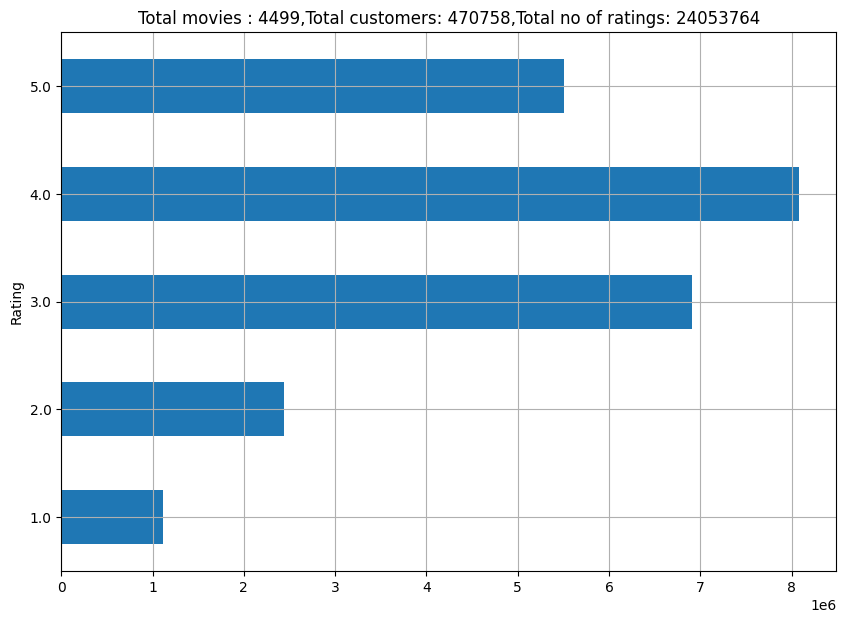

In [13]:
import matplotlib.pyplot as plt

ax = stars.plot(kind = 'barh',legend=False,figsize=(10,7))
plt.title(
    f'Total movies : {movie_count},'
    f'Total customers: {customer_count},'
    f'Total no of ratings: {rating_count}'
)
plt.grid(True)
plt.show()

In [ ]:
netflix_dataset

In [14]:
movie_id = None ## Currently i dont know which movie we are looking at
movie_np = [] ## list will store the movie corresponding to every row

for i in netflix_dataset['Cust_ID']:
  if ':' in i:
    movie_id = int(i.replace(':',""))
  movie_np.append(movie_id)

movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [18]:
## create a new column
netflix_dataset['Movie_Id'] = movie_np
netflix_dataset



ValueError: Length of values (24058263) does not match length of index (24053764)

In [21]:
netflix_dataset = netflix_dataset[
    netflix_dataset['Rating'].notna()
]
netflix_dataset

## Keep only the roes where rating is not empty

,Cust_ID,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
## netflix_dataset = netflix_dataset.dropna(subset=['Rating'])

In [22]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [24]:
## We are converting object type into int type
netflix_dataset['Cust_ID'] = netflix_dataset['Cust_ID'].astype(int)
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [ ]:
## Some users and some movies
''' Movie A has 2 ratings , User X ha 1 , pre filtering
Remove movies and users that dont have enough rating information

User A -> Rated 1 movie
User B -> rated 250 movie

In [27]:
dataset_movie_summary = netflix_dataset.groupby(
    'Movie_Id'
)['Rating'].agg(['count'])
## How many ratings does each movie have?

dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [31]:
movie_benchmark = round(
    dataset_movie_summary['count'].quantile(0.6),0
)
print(movie_benchmark)
## Find the 60th percentile of the number of ratings recieved by movies
## 908 reaings is the 60th percentile cutoff, users with fewer 908 ratings can be considered for removal


908.0


In [33]:
drop_movie_list = dataset_movie_summary[
    dataset_movie_summary['count'] < movie_benchmark
].index
drop_movie_list


Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [34]:
netflix_dataset = netflix_dataset[
    ~netflix_dataset['Movie_Id'].isin(drop_movie_list)
]

In [36]:
df_title = pd.read_csv(
    '/content/drive/MyDrive/Netflix/movies (1) (1).csv',
    encoding = 'ISO-8859-1',
    usecols = [0,1,2]
)
df_title

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [38]:
## rename the movieId to Movie_Id
df_title.rename(
    columns = {'movieId' : 'Movie_Id'},
    inplace = True
)

df_title

,Movie_Id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [39]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.8 MB/s eta 0:00:00


In [40]:
from surprise import Reader,Dataset,SVD
from surprise.model_selection import cross_validate

In [41]:
reader = Reader() ## Translator

In [43]:
data = Dataset.load_from_df(
    netflix_dataset[['Cust_ID','Movie_Id','Rating']][:100000], reader
)

In [44]:
model = SVD()

In [46]:
cross_validate(model,data,measures=['RMSE'],cv=3)


{'test_rmse': array([1.04142095, 1.05156658, 1.04458121]),
 'fit_time': (1.2787683010101318, 1.2582004070281982, 1.275012493133545),
 'test_time': (0.15970230102539062, 0.17156720161437988, 0.16744470596313477)}

In [48]:
## Prediction Part

user_rating = netflix_dataset[netflix_dataset['Cust_ID'] == 1331154]

user_rating

,Cust_ID,Rating,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [49]:
user_1331154 = df_title.copy()


In [50]:
user_1331154 = user_1331154[
    ~user_1331154['Movie_Id'].isin(drop_movie_list)
]

In [51]:
## Predict the rating
user_1331154['Estimated_Score'] = user_1331154['Movie_Id'].apply(lambda x : model.predict(1331154,x).est)
## predict the rating that the user 1331154 would given to movie X

In [52]:
model.predict(1331154,1)

Prediction(uid=1331154, iid=1, r_ui=None, est=np.float64(3.5030394729740197), details={'was_impossible': False})

In [53]:
user_1331154

,Movie_Id,title,genres,Estimated_Score
2,3,Grumpier Old Men (1995),Comedy|Romance,4.079096
4,5,Father of the Bride Part II (1995),Comedy,3.569762
5,6,Heat (1995),Action|Crime|Thriller,2.904362
7,8,Tom and Huck (1995),Adventure|Children,3.293415
15,16,Casino (1995),Crime|Drama,3.043933
...,...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy,3.503039
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,3.503039
27275,131258,The Pirates (2014),Adventure,3.503039
27276,131260,Rentun Ruusu (2001),(no genres listed),3.503039


In [54]:
user_1331154.sort_values('Estimated_Score',ascending=False,inplace=True)

In [55]:
user_1331154.head(5)

,Movie_Id,title,genres,Estimated_Score
27,28,Persuasion (1995),Drama|Romance,4.208483
2,3,Grumpier Old Men (1995),Comedy|Romance,4.079096
24,25,Leaving Las Vegas (1995),Drama|Romance,4.035081
29,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,4.015636
17,18,Four Rooms (1995),Comedy,3.815563
